## Task 2: Storytelling Dashboard (Subplot Grid) [Hard]
choose a dataset with at least 3 numeric and 2 categorical columns. Build a 2x2 subplot figure that tells a cohesive story - each panel must connect to a central theme (e.g., 'customer behaviour').
Apply a consistent color palette, shared lengends, proper annotations, and export at 300 dpi. write a 3-sentence narrative summary at the top of your notebook explaining the story.

# TV Show Analytics Dashboard

This dashboard analyzes how different TV show characteristics relate to audience ratings and production trends over time. 
The visualizations compare average ratings across show types, examine rating distributions, explore the relationship between show duration and ratings, and track the growth of TV show releases across years. 
Together, these insights highlight how production patterns and content characteristics may influence audience engagement and overall show success.

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv(r"..\..\week_4(ETL_Data_Cleaning)\Task_8\tvmaze_cleaned.csv")

df.head()

,id,url,name,type,language,genres,status,premiered,ended,summary,rating_average,schedule_time,schedule_days,premier_year,rating_category,summary_word_count,show_duration_years
0,1,https://www.tvmaze.com/shows/1/under-the-dome,Under the Dome,Scripted,English,"['Drama', 'Science-Fiction', 'Thriller']",Ended,2013-06-24,2015-09-10,Under the Dome is the story of a small town th...,6.6,22:00,Thursday,2013,Good,57,2.0
1,2,https://www.tvmaze.com/shows/2/person-of-interest,Person of Interest,Scripted,English,"['Action', 'Crime', 'Science-Fiction']",Ended,2011-09-22,2016-06-21,You are being watched. The government has a se...,8.8,22:00,Tuesday,2011,Excellent,96,5.0
2,3,https://www.tvmaze.com/shows/3/bitten,Bitten,Scripted,English,"['Drama', 'Horror', 'Romance']",Ended,2014-01-11,2016-04-15,Based on the critically acclaimed series of no...,7.4,22:00,Friday,2014,Good,75,2.0
3,4,https://www.tvmaze.com/shows/4/arrow,Arrow,Scripted,English,"['Drama', 'Action', 'Science-Fiction']",Ended,2012-10-10,2020-01-28,"After a violent shipwreck, billionaire playboy...",7.4,21:00,Tuesday,2012,Good,85,8.0
4,5,https://www.tvmaze.com/shows/5/true-detective,True Detective,Scripted,English,"['Drama', 'Crime', 'Thriller']",Running,2014-01-12,NaN,Touch darkness and darkness touches you back. ...,8.1,21:00,Sunday,2014,Excellent,47,12.0


### Basic Cleaning

In [3]:
# =========================
# BASIC CLEANING
# =========================

# Check dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Remove rows where rating is missing
df = df.dropna(subset=["rating_average"])

# Convert date columns to datetime
df["premiered"] = pd.to_datetime(df["premiered"], errors="coerce")
df["ended"] = pd.to_datetime(df["ended"], errors="coerce")

# Remove duplicate rows if any
df = df.drop_duplicates()

# Clean text columns
df["name"] = df["name"].str.strip()
df["language"] = df["language"].str.strip()
df["type"] = df["type"].str.strip()

# Ensure numerical columns are proper numeric types
numeric_cols = [
    "rating_average",
    "premier_year",
    "summary_word_count",
    "show_duration_years"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with invalid years
df = df[df["premier_year"] > 1900]

# Final shape after cleaning
print("Cleaned Dataset Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   240 non-null    int64  
 1   url                  240 non-null    str    
 2   name                 240 non-null    str    
 3   type                 240 non-null    str    
 4   language             240 non-null    str    
 5   genres               240 non-null    str    
 6   status               240 non-null    str    
 7   premiered            240 non-null    str    
 8   ended                219 non-null    str    
 9   summary              240 non-null    str    
 10  rating_average       240 non-null    float64
 11  schedule_time        225 non-null    str    
 12  schedule_days        235 non-null    str    
 13  premier_year         240 non-null    int64  
 14  rating_category      240 non-null    str    
 15  summary_word_count   240 non-null    int64  
 16  s

### Create 2x2 Storytelling Dashboard

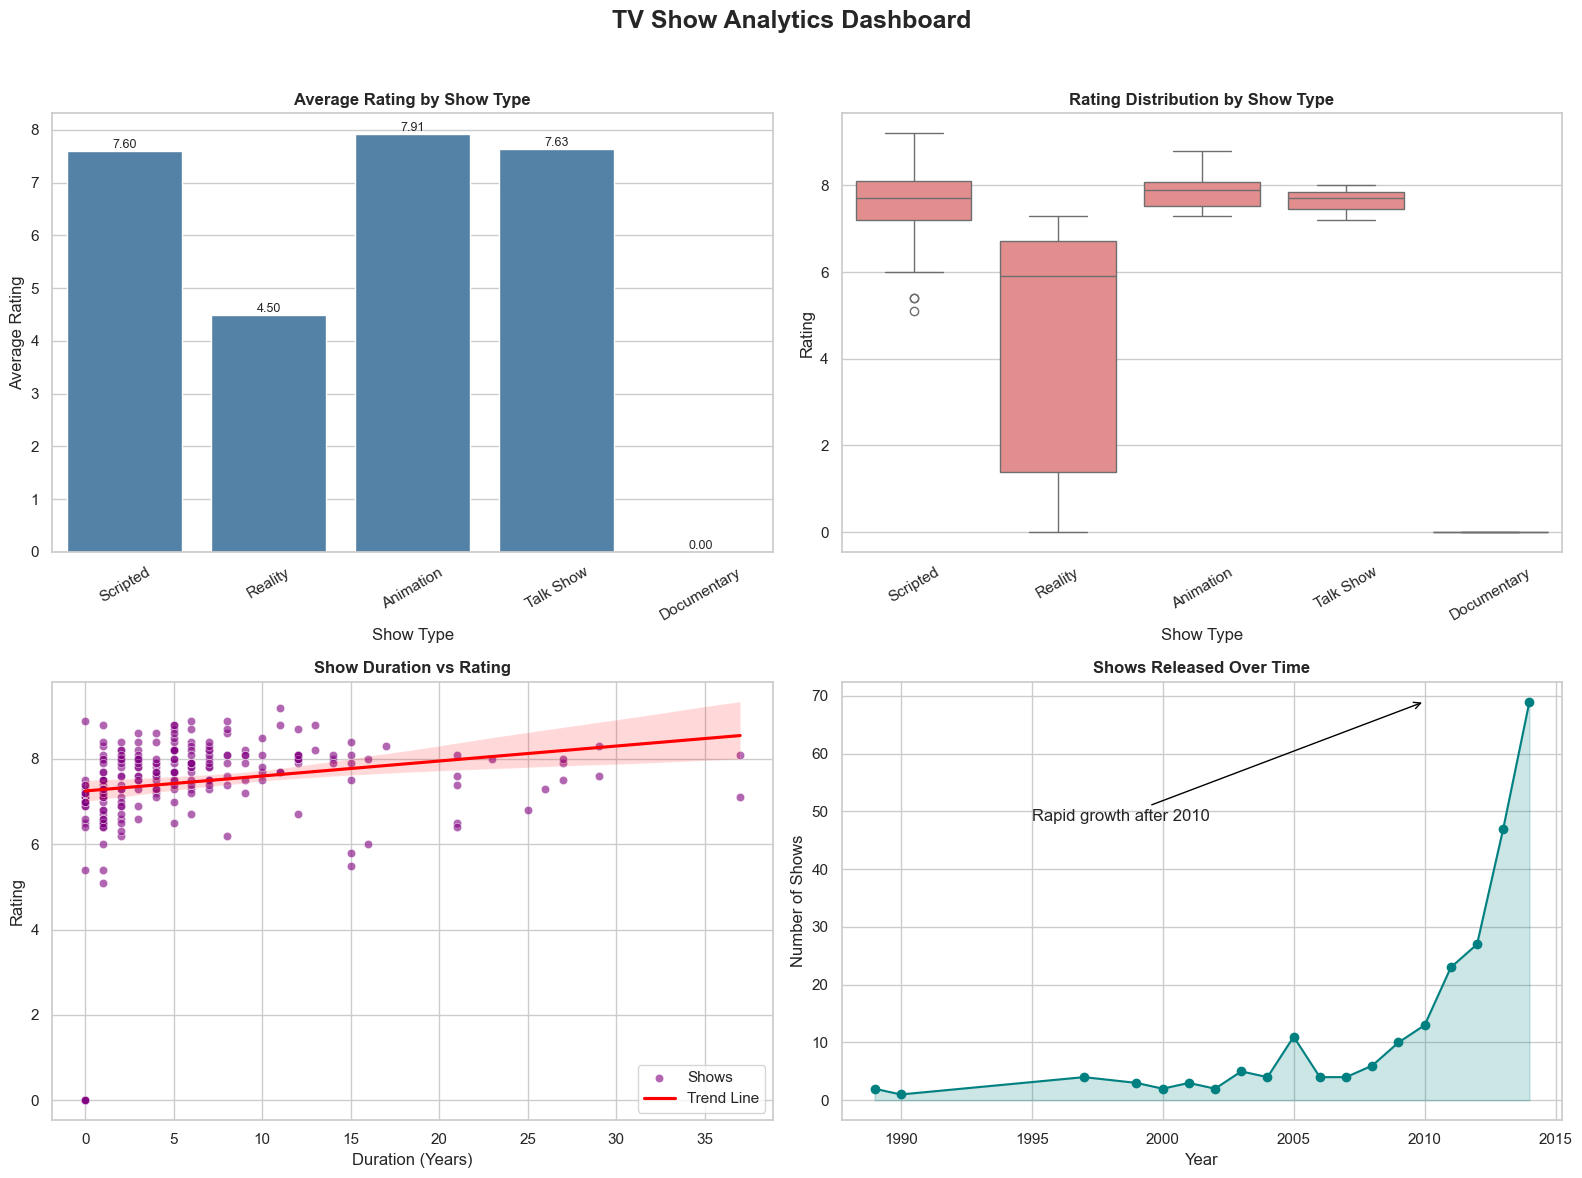

In [12]:
# -----------------------
# STYLE SETUP
# -----------------------
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================
# 1. BARPLOT
# Average Rating by Type
# =========================
sns.barplot(
    data=df,
    x="type",
    y="rating_average",
    ax=axes[0, 0],
    color="steelblue",
    errorbar=None
)

axes[0, 0].set_title("Average Rating by Show Type", fontweight="bold")
axes[0, 0].set_xlabel("Show Type")
axes[0, 0].set_ylabel("Average Rating")
axes[0, 0].tick_params(axis='x', rotation=30)

# value labels
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom',
        fontsize=9
    )

# =========================
# 2. BOXPLOT
# Rating Distribution by Type
# =========================
sns.boxplot(
    data=df,
    x="type",
    y="rating_average",
    ax=axes[0, 1],
    color="lightcoral"
)

axes[0, 1].set_title("Rating Distribution by Show Type", fontweight="bold")
axes[0, 1].set_xlabel("Show Type")
axes[0, 1].set_ylabel("Rating")
axes[0, 1].tick_params(axis='x', rotation=30)

# =========================
# 3. SCATTERPLOT
# Duration vs Rating
# =========================
sns.scatterplot(
    data=df,
    x="show_duration_years",
    y="rating_average",
    ax=axes[1, 0],
    color="purple",
    alpha=0.6,
    label="Shows"
)

sns.regplot(
    data=df,
    x="show_duration_years",
    y="rating_average",
    ax=axes[1, 0],
    scatter=False,
    color="red",
    label="Trend Line"
)

axes[1, 0].legend()

axes[1, 0].set_title("Show Duration vs Rating", fontweight="bold")
axes[1, 0].set_xlabel("Duration (Years)")
axes[1, 0].set_ylabel("Rating")

# =========================
# 4. LINE PLOT
# Shows per Year Trend
# =========================
year_data = df["premier_year"].value_counts().sort_index()

axes[1, 1].plot(
    year_data.index,
    year_data.values,
    marker='o',
    color='teal'
)

axes[1, 1].fill_between(
    year_data.index,
    year_data.values,
    color='teal',
    alpha=0.2
)

axes[1, 1].set_title("Shows Released Over Time", fontweight="bold")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Number of Shows")

# annotation
axes[1, 1].annotate(
    "Rapid growth after 2010",
    xy=(2010, max(year_data.values)),
    xytext=(1995, max(year_data.values)*0.7),
    arrowprops=dict(arrowstyle="->", color="black")
)

# -----------------------
# FINAL LAYOUT
# -----------------------
plt.suptitle(
    "TV Show Analytics Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save high-quality output
plt.savefig("tv_show_dashboard.png", dpi=300)

plt.show()

### Key Insights from the Dashboard
1. Average Rating by Show Type

Animation shows have the highest average ratings, while Reality shows tend to receive comparatively lower audience ratings.

2. Rating Distribution by Show Type

Scripted, Animation, and Talk Show categories maintain consistently high ratings with smaller variation, whereas Reality shows display a much wider spread and lower median ratings.

3. Show Duration vs Rating

Longer-running shows show a slight positive relationship with ratings, suggesting that successful shows are more likely to continue for multiple years.

4. Shows Released Over Time

TV show production increased rapidly after 2010, indicating significant growth in content creation during the streaming and digital entertainment era.

Overall Dashboard Insight

The dashboard suggests that show format, longevity, and industry production growth all play an important role in shaping audience ratings and television trends.